In [12]:
import numpy as np
import pandas as pd
import cv2 as cv
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
from IPython.display import clear_output
from torch.optim.lr_scheduler import StepLR
from models.generator import ColorGenerator
from preprocessing import normalizeLAB, denormalizeLAB

In [13]:
device = "cuda"

# Import Data

In [14]:
imgs = np.load("./dataset/labs.npy")
masks = np.load("./dataset/masks.npy")

In [15]:
class ImagesDataset(Dataset):
    def __init__(self, imgs, masks):
        assert(imgs.shape[0] == masks.shape[0])
        self.imgs = imgs
        self.masks = masks

    def __len__(self):
        return len(self.imgs)
    
    def __getitem__(self, idx):
        return (self.imgs[idx], self.masks[idx])

In [16]:
train_num = int(len(imgs) * 0.8)

train = ImagesDataset(imgs[:train_num], masks[:train_num])
test = ImagesDataset(imgs[train_num:], masks[train_num:])

In [17]:
train_loader = DataLoader(train,batch_size=128,shuffle=True)

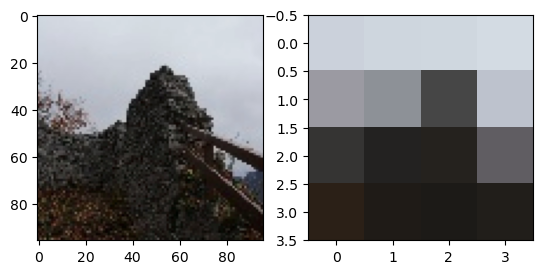

In [18]:
test_image, test_mask = train[100]

real = cv.cvtColor(denormalizeLAB(test_image), code=cv.COLOR_LAB2RGB)
mask = cv.cvtColor(denormalizeLAB(test_mask), code=cv.COLOR_LAB2RGB)

plt.subplot(1,2,1).imshow(real)
plt.subplot(1,2,2).imshow(mask)

# Build model

In [19]:
lr = 1e-3
epochs = 200

n_cell = 4
model = ColorGenerator(output_chanels=2,n_cell=n_cell).to(device)
optimizer = AdamW(params=model.parameters(),lr=lr)
criterion = nn.L1Loss()
scheduler = StepLR(optimizer, step_size=50, gamma=0.1)

In [20]:
def show_samples(generator, img, c, epoch):

    show_results(generator, img, c)

    plt.suptitle(f"Epoch = {epoch}")
    plt.savefig(f"CNN-model/train-results/{epoch}.png")
    plt.show()

def show_results(generator, img, c):
    if type(img) == np.ndarray: img = torch.tensor(img)
    if type(c) == np.ndarray: c = torch.tensor(c)

    img = img.to(torch.float32).to(device)
    c = c.to(torch.float32).to(device)

    img = torch.moveaxis(img,-1,-3)
    c = torch.moveaxis(c,-1,-3)

    x = img[:,:1,...]
    y = img[:,1:,...]
    x_hat = generator(x,c)
    x_hat = torch.concat([x,x_hat],dim=1).detach().cpu().numpy()
    x_hat = np.moveaxis(x_hat,-3,-1)
    x_hat = denormalizeLAB(x_hat)

    img = img.clone().detach().cpu().numpy()
    img = np.moveaxis(img,-3,-1)
    img = denormalizeLAB(img)

    n = img.shape[0]

    x = x.detach().cpu().numpy()
    fig, axs = plt.subplots(3,n,figsize=(n,4))

    for i in range(n):
        colored = cv.cvtColor(x_hat[i],code=cv.COLOR_LAB2RGB)
        real = cv.cvtColor(img[i],code=cv.COLOR_LAB2RGB)
        axs[0][i].imshow(real)
        axs[1][i].imshow(x[i][0],cmap="grey")
        axs[2][i].imshow(colored)

        for ax in axs.flat: ax.axis("off")
    
    axs[0][0].set_title("Real color")
    axs[1][0].set_title("Grayscale input")
    axs[2][0].set_title("Generated color")

# Train model

In [21]:
sample_x, sample_c = test[[1,30,100,-100,-30,-1]]

epoch 200 loss: 0.01984034851193428 [lr: [1.0000000000000002e-06]]


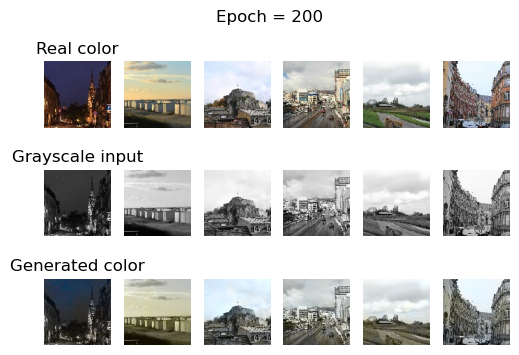

In [22]:
training_loss = []

for epoch in range(epochs):

    epoch_loss = .0

    for idx, batch in enumerate(train_loader):
        img, c = batch
        img = torch.moveaxis(img,-1,-3).to(torch.float32).to(device)
        
        x = img[:,:1,...]
        y = img[:,1:,...]
        
        c = torch.moveaxis(c,-1,-3).to(torch.float32).to(device)

        y_hat = model(x,c)
        loss = criterion(y,y_hat)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss = loss.item()
        
    clear_output()
    print(f"epoch {epoch + 1} loss: {epoch_loss} [lr: {scheduler.get_last_lr()}]")
    show_samples(model, sample_x, sample_c,epoch + 1)

    scheduler.step()
    training_loss.append(epoch_loss)
    

In [23]:
y_hat.shape

torch.Size([4, 2, 96, 96])

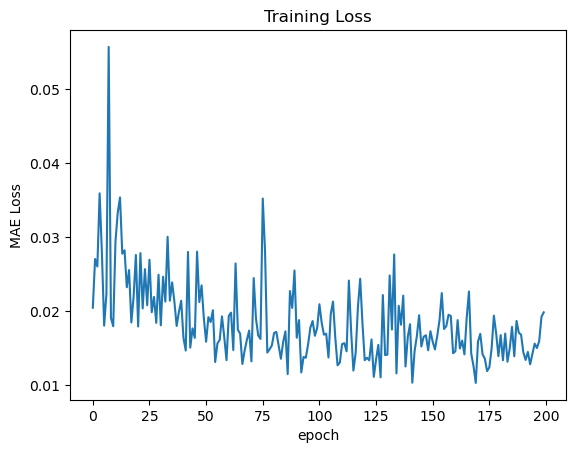

In [24]:
plt.plot(training_loss)
plt.title("Training Loss")
plt.xlabel("epoch")
plt.ylabel("MAE Loss")
plt.savefig("CNN-model/training-loss.png")

In [36]:
from PIL import Image
import os

frames = []
for i in range(epochs):
    frame = Image.open(f"CNN-model/train-results/{i+1}.png")
    frames.append(frame)

frames[0].save("CNN-model/train-results.gif", 
               save_all = True,
               append_images = frames[1:],
               duration = 100,
               loop = 0)

# Test

In [26]:
test_loader = DataLoader(test, batch_size=16)

In [27]:
def test_model(generator, batch, idx):

    show_results(generator, *batch)

    plt.suptitle(f"Colorization results")
    plt.savefig(f"CNN-model/test-results/{idx}.png")
    plt.show()

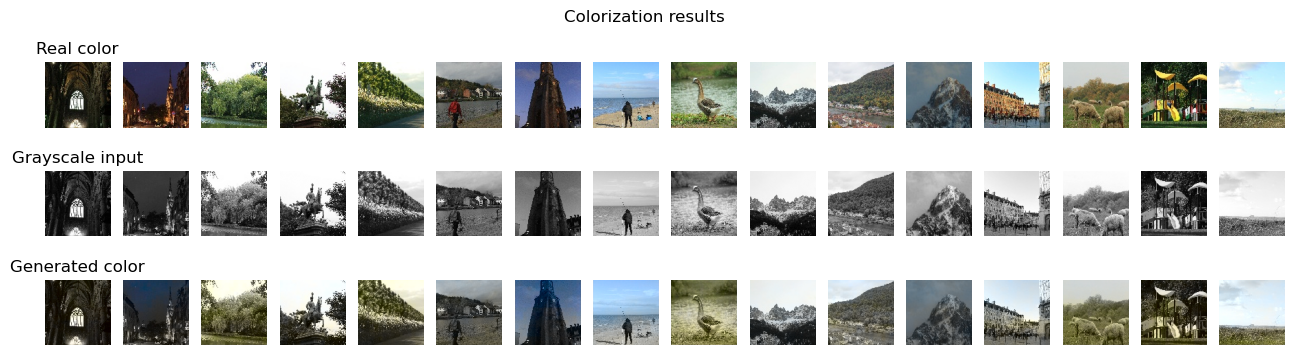

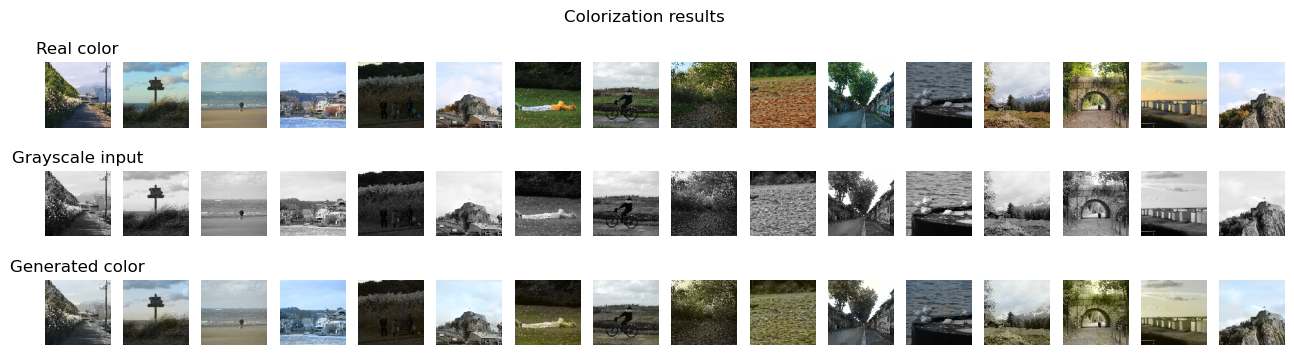

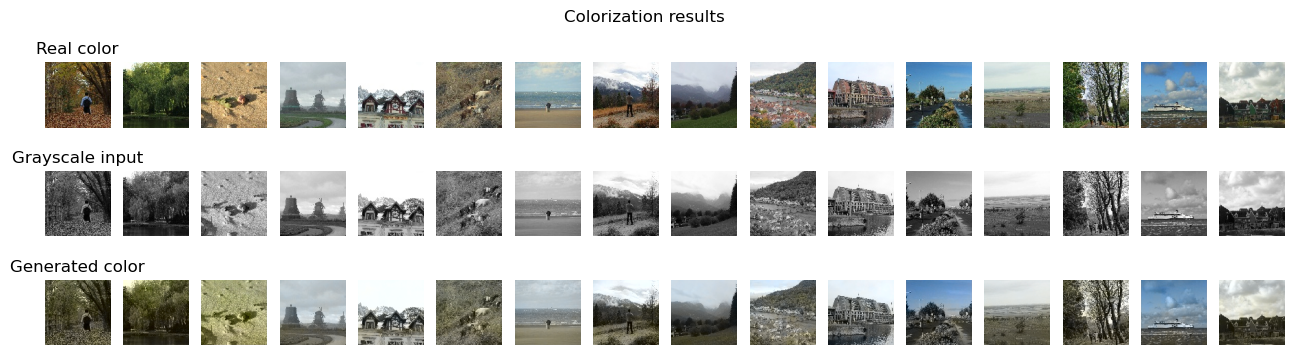

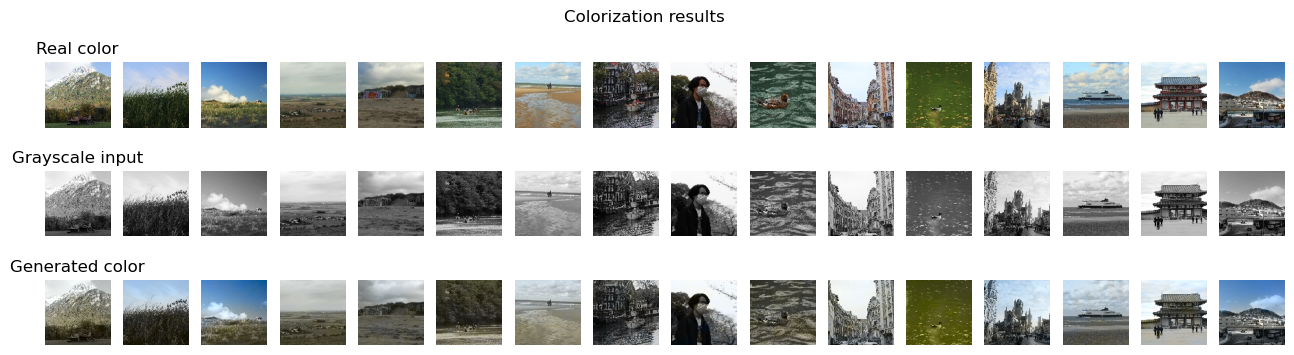

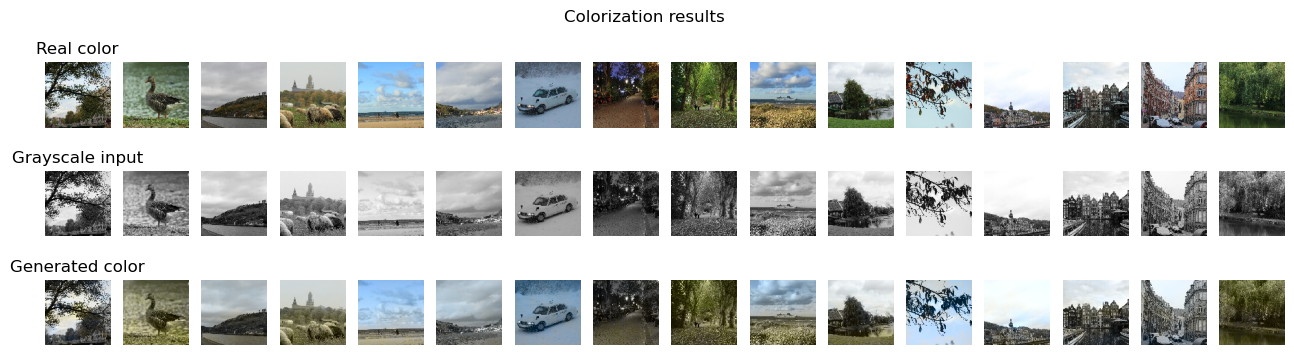

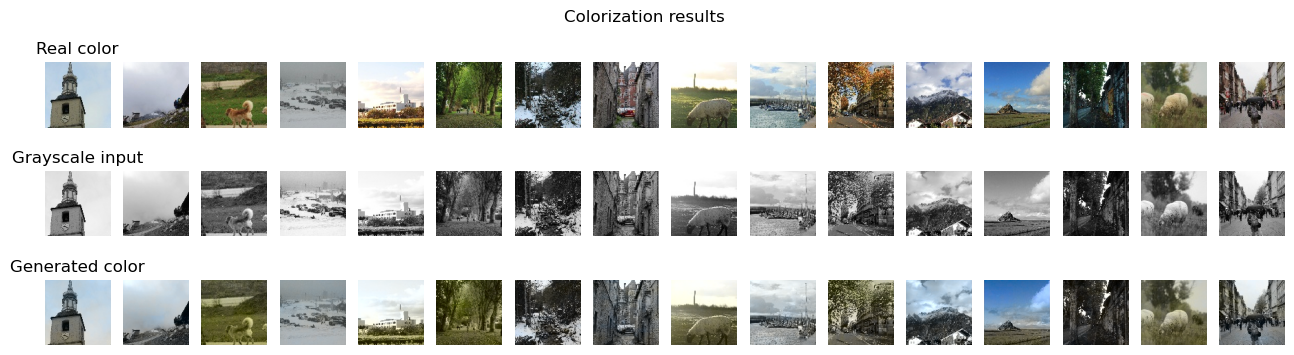

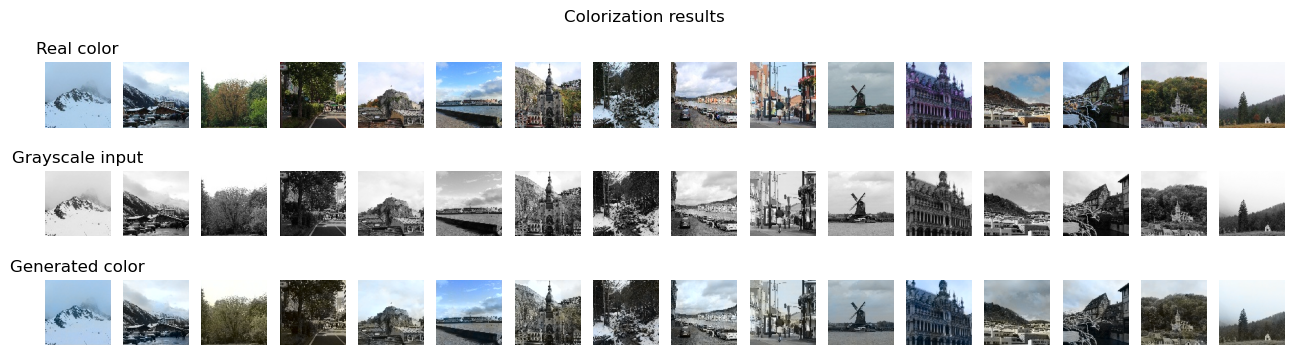

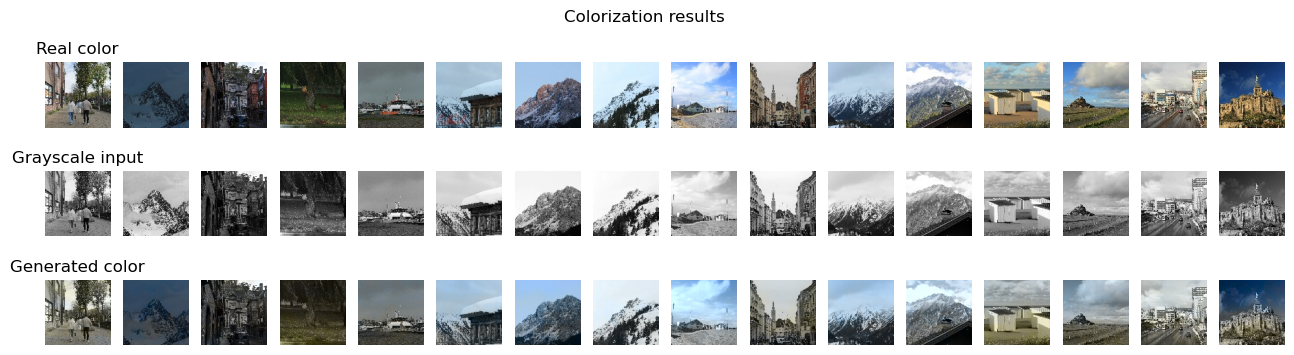

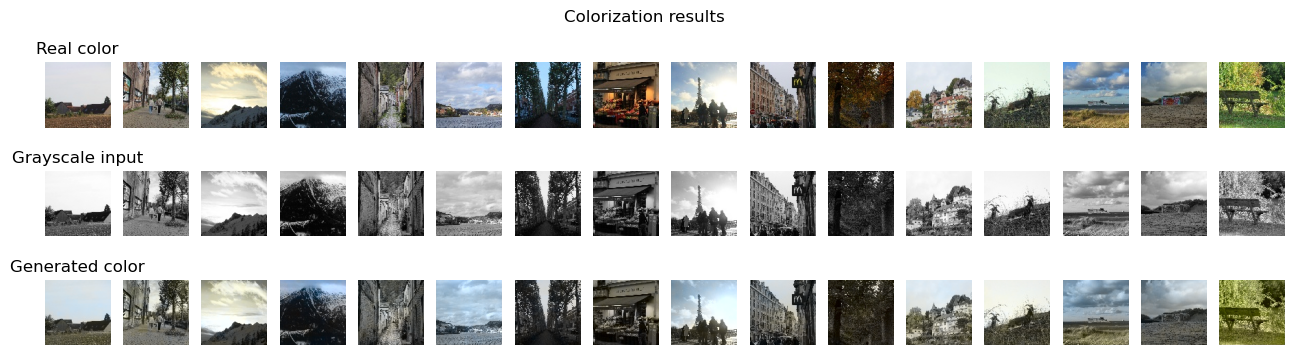

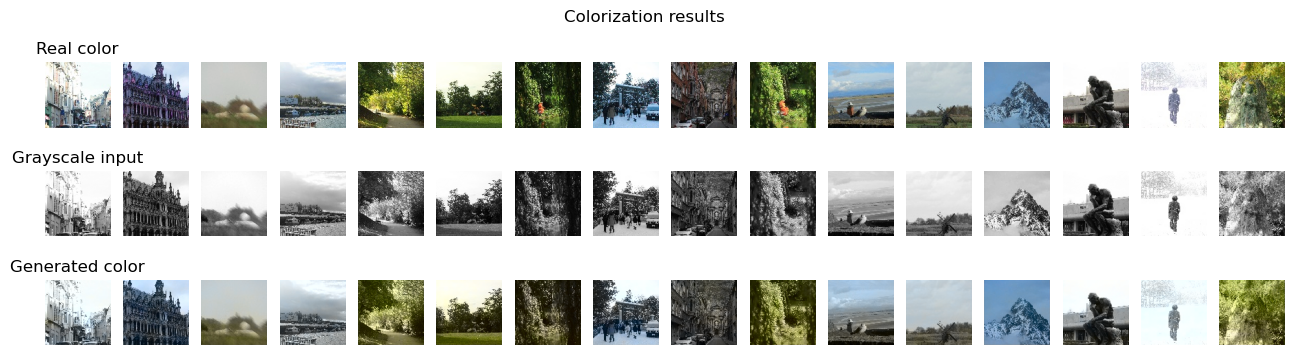

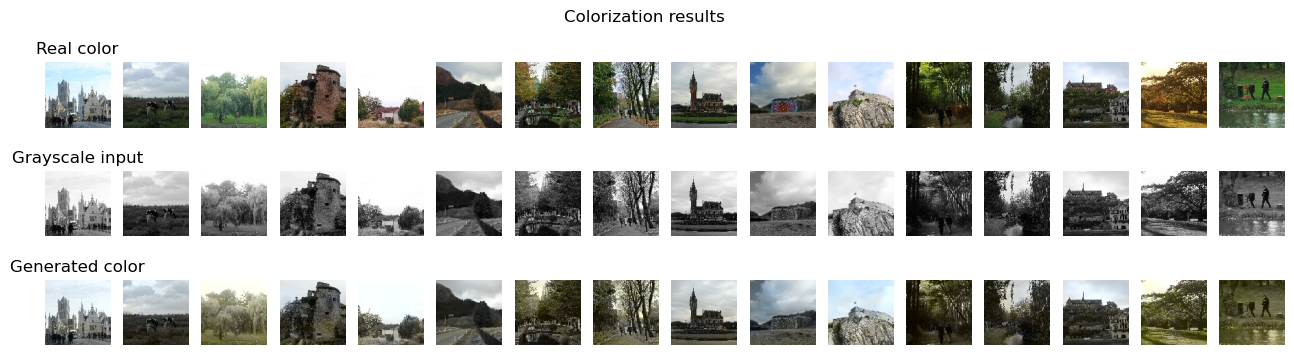

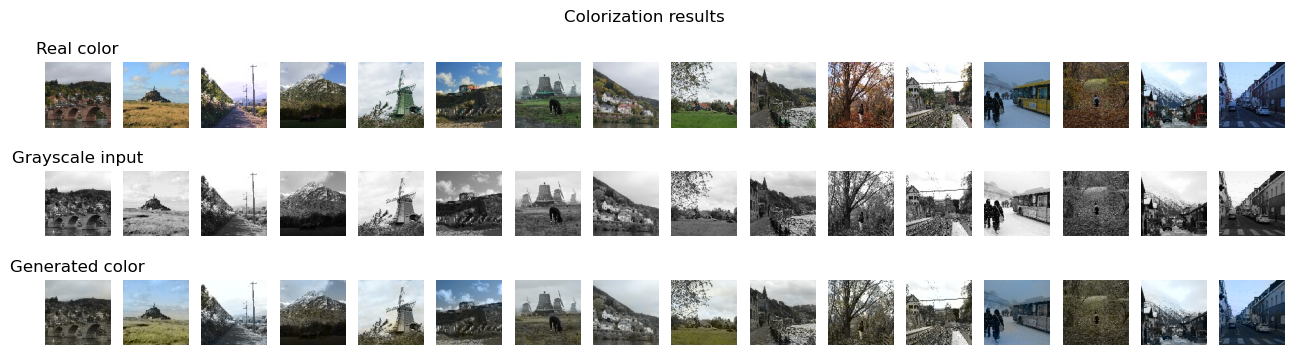

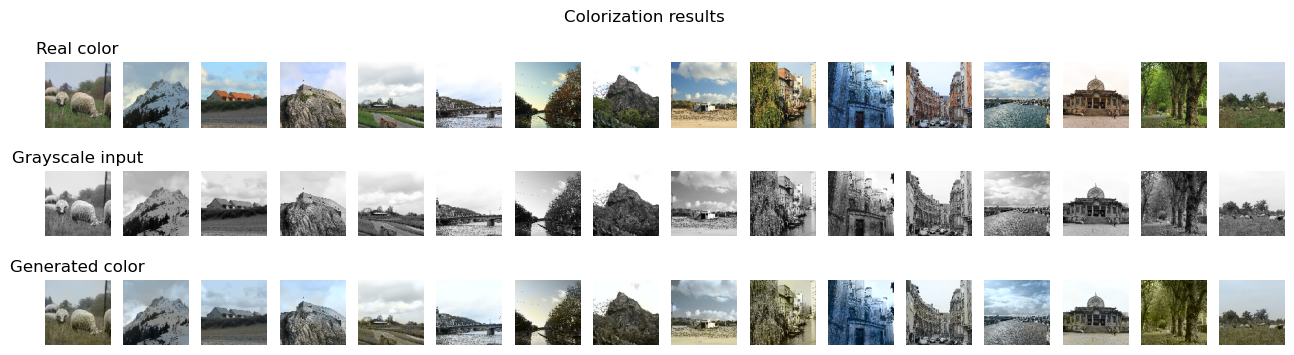

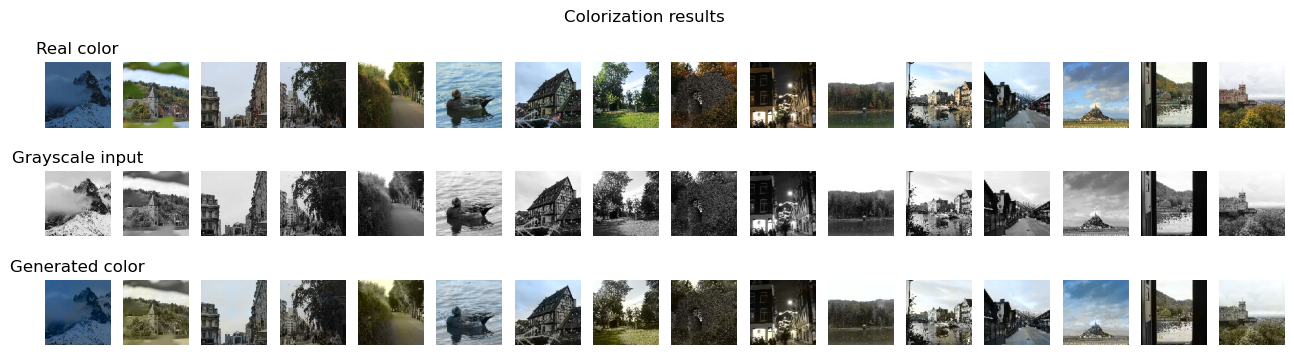

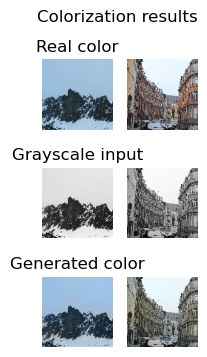

In [28]:
for idx, batch in enumerate(test_loader):
    test_model(model, batch, idx)

# Test with custom colors

In [29]:
def maskRandomShift(mask, alpha = 0.05, sign = 1, a_sign = None, b_sign = None):
    dummy_mask = mask.copy()
    diff = np.random.random([2])

    if a_sign == None: a_sign = sign
    if b_sign == None: b_sign = sign

    dummy_mask[...,1] = dummy_mask[...,1] * (1-alpha) + diff[0] * alpha * a_sign
    dummy_mask[...,2] = dummy_mask[...,2] * (1-alpha) + diff[1] * alpha * b_sign

    return dummy_mask

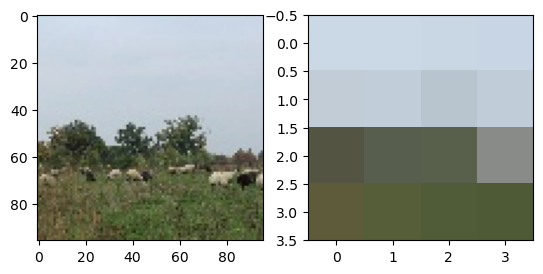

In [37]:

test_image, test_mask = test[-19]
real = cv.cvtColor(denormalizeLAB(test_image), code=cv.COLOR_LAB2RGB)
mask = cv.cvtColor(denormalizeLAB(test_mask), code=cv.COLOR_LAB2RGB)

plt.subplot(1,2,1).imshow(real)
plt.subplot(1,2,2).imshow(mask)

Text(0.5, 1.0, 'Modified mask')

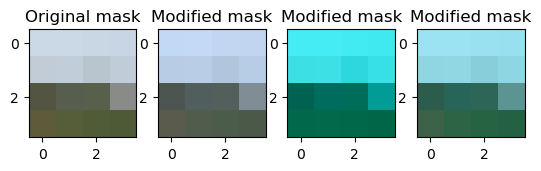

In [38]:
dummy_mask_1 = maskRandomShift(test_mask, alpha = 0.15, a_sign = 1, b_sign = 1)
rgb_mask_1 = cv.cvtColor(denormalizeLAB(dummy_mask_1), code=cv.COLOR_LAB2RGB)
dummy_mask_2 = maskRandomShift(test_mask, alpha = 0.15, a_sign = -1, b_sign = 1)
rgb_mask_2 = cv.cvtColor(denormalizeLAB(dummy_mask_2), code=cv.COLOR_LAB2RGB)
dummy_mask_3 = maskRandomShift(test_mask, alpha = 0.05, sign = -1)
rgb_mask_3 = cv.cvtColor(denormalizeLAB(dummy_mask_3), code=cv.COLOR_LAB2RGB)


fig, axs = plt.subplots(1,4)
axs[0].imshow(mask)
axs[0].set_title("Original mask")
axs[1].imshow(rgb_mask_1)
axs[1].set_title("Modified mask")
axs[2].imshow(rgb_mask_2)
axs[2].set_title("Modified mask")
axs[3].imshow(rgb_mask_3)
axs[3].set_title("Modified mask")

In [ ]:

def show_color_changes(generator, img, c):
    img = torch.tensor(img)
    c = torch.tensor(c)

    img = img.to(torch.float32).to(device)
    c = c.to(torch.float32).to(device)

    img = torch.moveaxis(img,-1,-3)
    c = torch.moveaxis(c,-1,-3)

    x = img[:,:1,...]
    y = img[:,1:,...]
    x_hat = generator(x,c)
    x_hat = torch.concat([x,x_hat],dim=1).detach().cpu().numpy()
    x_hat = np.moveaxis(x_hat,-3,-1)
    x_hat = denormalizeLAB(x_hat)

    masks = c.clone().detach().cpu().numpy()
    masks = np.moveaxis(masks,-3,-1)
    masks = denormalizeLAB(masks)

    n = masks.shape[0]

    x = x.detach().cpu().numpy()
    fig, axs = plt.subplots(3,n,figsize=(n,4))

    for i in range(n):
        colored = cv.cvtColor(x_hat[i],code=cv.COLOR_LAB2RGB)
        real = cv.cvtColor(masks[i],code=cv.COLOR_LAB2RGB)
        axs[0][i].imshow(real)
        axs[1][i].imshow(x[i][0],cmap="grey")
        axs[2][i].imshow(colored)

        for ax in axs.flat: ax.axis("off")
    
    axs[0][0].set_title("Color masks")
    axs[1][0].set_title("Grayscale input")
    axs[2][0].set_title("Generated color")


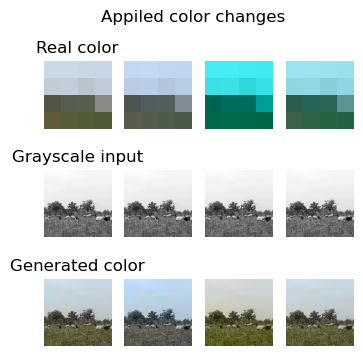

In [40]:
test_x = np.stack([test_image] * 4)
test_c = np.stack([test_mask, dummy_mask_1, dummy_mask_2, dummy_mask_3])

show_color_changes(model, test_x, test_c)
plt.suptitle(f"Appiled color changes")
plt.savefig(f"CNN-model/appiled-color-masks.png")